<a href="https://colab.research.google.com/github/Sakhiur2022/Signal/blob/main/notebooks/07_interaction_analysis/01_interaction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPR-07 — Interaction Analysis

**Ticket:** SPR-07
**Owner:** Prithila
**Depends on:** SPR-06 (subgroup analysis, read the notebook, do not edit it)
**Folder:** `notebooks/07_interaction_analysis/`
**Output:** at least one interaction effect confirmed or ruled out

**No reference notebook covers this.** Built from the project's original core result: digital_index has a monotonically increasing association with income class via MNLogit. This notebook tests whether that association is stronger or weaker within specific subgroups, using formal interaction terms rather than the descriptive SHAP split from SPR-06.

## 0. Hugging Face setup: login and download data/models
Run this once per Colab session. It authenticates against the `Sakhiur/signal` repo and pulls the CSVs used below. Add your token in Colab's left sidebar (key icon) under the name `HF_TOKEN` before running this cell.

In [7]:
!wget -q https://huggingface.co/datasets/Sakhiur/signal/resolve/main/final_dataset_preprocessed_distributed_social_class.csv

In [8]:
!pip install -q huggingface_hub

import os
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

REPO_ID = 'Sakhiur/signal'

os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

hf_files = {
    'X_test_Sakhiur.csv': 'data/interim/X_test.csv',
    'X_train_resampled_Sakhiur.csv': 'data/interim/X_train_resampled.csv',
    'y_test_Sakhiur.csv': 'data/interim/y_test.csv',
    'y_train_resampled_Sakhiur.csv': 'data/interim/y_train_resampled.csv',
}

for repo_filename, local_path in hf_files.items():
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type='dataset',
        filename=repo_filename,
    )
    import shutil
    shutil.copy(downloaded, local_path)
    print(f'{repo_filename} -> {local_path}')

print('All data files ready.')

X_test_Sakhiur.csv -> data/interim/X_test.csv
X_train_resampled_Sakhiur.csv -> data/interim/X_train_resampled.csv
y_test_Sakhiur.csv -> data/interim/y_test.csv
y_train_resampled_Sakhiur.csv -> data/interim/y_train_resampled.csv
All data files ready.


## 1. Load data and subgroup findings from SPR-06

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv('final_dataset_preprocessed_distributed_social_class.csv')
# subgroup_results = pd.read_csv('results/tables/subgroup_analysis.csv')
subgroup_results = pd.read_csv('subgroup_analysis.csv')

print('Subgroup findings from SPR-06 (read-only reference):')
print(subgroup_results.sort_values('mean_abs', ascending=False).head(10))

Subgroup findings from SPR-06 (read-only reference):
               group      mean       std  count  mean_abs subgroup_dimension
2               Agri -0.904838  0.373706      7  0.904838         agri_group
9            Eastern -0.812933  0.418920     55  0.884917       region_group
10              Java -0.645701  0.720762    129  0.881877       region_group
8          Bali_Nusa -0.739480  0.507689     34  0.860770       region_group
6             Female -0.680679  0.559592    251  0.840250       gender_group
1    Lower_education -0.760389  0.456054    203  0.829971          edu_group
4           Disabled -0.720675  0.467737     33  0.823161   disability_group
5       Non_disabled -0.613562  0.634626    467  0.807538   disability_group
3           Non_agri -0.616596  0.627333    493  0.807203         agri_group
0   Higher_education -0.525107  0.703149    297  0.793941          edu_group


## 2. Re-fit the core MNLogit with an interaction term
Same model family as the original core result (`statsmodels.MNLogit`), now with `digital_index * education_years` added as an interaction term. Start with the subgroup that showed the strongest effect in SPR-06's output; swap `education_years` for another candidate if SPR-06 pointed elsewhere.

In [22]:
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# 1. Copy data
df_model = df.copy()

# 2. Income class coding
class_order = ['No_income', 'Lower', 'Middle', 'Upper']

cat_type = CategoricalDtype(
    categories=class_order,
    ordered=False
)

df_model['income_class_code'] = (
    df_model['income_class']
    .astype(cat_type)
    .cat.codes
)


# 3. STANDARDIZE ONLY CONTINUOUS VARIABLES
continuous_cols = [
    'digital_index',
    'education_years',
    'age',
    'weekly_workhours',
    'social_participation_index'
]

scaler = StandardScaler()

df_model[continuous_cols] = scaler.fit_transform(
    df_model[continuous_cols]
)


# 4. MODEL
formula = (
    'income_class_code ~ '
    'digital_index * education_years '
    '+ age '
    '+ weekly_workhours '
    '+ gender_male '
    '+ disabled '
    '+ agri_worker '
    '+ social_participation_index'
)

model = smf.mnlogit(
    formula,
    data=df_model
)


# 5. FIT
result = model.fit(
    method='lbfgs',
    maxiter=1000,
    disp=True
)



# 6. CHECK
print("\nModel converged:",
      result.mle_retvals['converged'])

print("Iterations:",
      result.mle_retvals['iterations'])

print("\nClass code mapping:")
for i, cls in enumerate(class_order):
    print(f"  {i} -> {cls}")



print(result.summary())


Model converged: True
Iterations: 180

Class code mapping:
  0 -> No_income
  1 -> Lower
  2 -> Middle
  3 -> Upper
                          MNLogit Regression Results                          
Dep. Variable:      income_class_code   No. Observations:               751622
Model:                        MNLogit   Df Residuals:                   751592
Method:                           MLE   Df Model:                           27
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                  0.4318
Time:                        15:11:16   Log-Likelihood:            -4.7665e+05
converged:                       True   LL-Null:                   -8.3885e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
          income_class_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.2276      0.006    

## 3. Interpret the interaction coefficient
A significant `digital_index:education_years` coefficient means the effect of digital access on income class genuinely depends on education level, not just that both matter separately. This is the difference between confirming and ruling out the interaction.

In [23]:
TARGET_COL = 'income_class'

In [24]:
INTERACTION_FEATURE = 'education_years'

In [25]:
params = result.params
pvalues = result.pvalues

interaction_term = f'digital_index:{INTERACTION_FEATURE}'
print(f'Interaction term: {interaction_term}')
print()
print('Coefficients across income class equations:')
print(params.loc[interaction_term] if interaction_term in params.index else 'Term not found, check formula output above')
print()
print('P-values across income class equations:')
print(pvalues.loc[interaction_term] if interaction_term in pvalues.index else 'Term not found')

Interaction term: digital_index:education_years

Coefficients across income class equations:
0    0.197697
1    0.237881
2    0.258593
Name: digital_index:education_years, dtype: float64

P-values across income class equations:
0    1.179771e-165
1    4.991613e-210
2     2.491930e-77
Name: digital_index:education_years, dtype: float64


## 4. Predicted probability interaction plot: digital access at different education levels
Visualizes the interaction directly, rather than reading it off a coefficient table. Predicts probability of the highest income class across the digital_index range, at low vs high education.

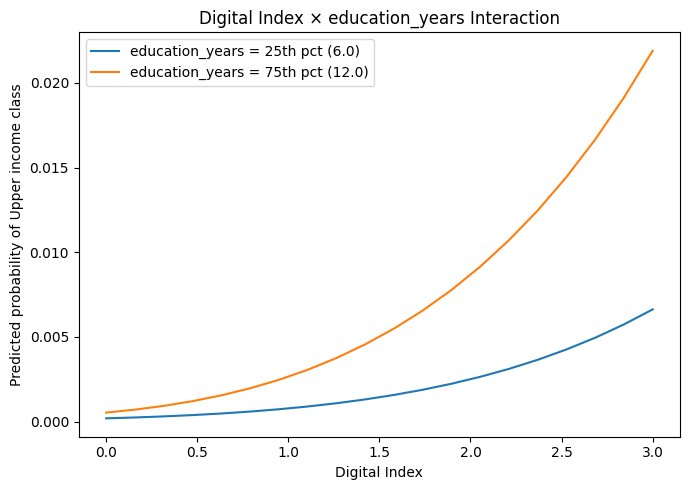

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Education values in ORIGINAL units
edu_low = df[INTERACTION_FEATURE].quantile(0.25)
edu_high = df[INTERACTION_FEATURE].quantile(0.75)

# Digital index range in ORIGINAL units
digital_range = np.linspace(
    df['digital_index'].min(),
    df['digital_index'].max(),
    20
)

# Typical observation using original data
base_row = df.drop(
    columns=[TARGET_COL],
    errors='ignore'
).median(numeric_only=True)


def predict_prob_curve(edu_value):

    rows = []

    for d in digital_range:

        row = base_row.copy()

        row['digital_index'] = d
        row[INTERACTION_FEATURE] = edu_value

        rows.append(row)

    pred_df = pd.DataFrame(rows)


    # IMPORTANT:Apply SAME scaling used for training
    pred_df[continuous_cols] = scaler.transform(
        pred_df[continuous_cols]
    )

    # Predict class probabilities
    probs = result.predict(pred_df)

    return probs


# Predictions
probs_low_edu = predict_prob_curve(edu_low)
probs_high_edu = predict_prob_curve(edu_high)


# Class 3 = Upper
upper_class_col = 3


# Plot
plt.figure(figsize=(7, 5))

plt.plot(
    digital_range,
    probs_low_edu[upper_class_col],
    label=f'{INTERACTION_FEATURE} = 25th pct ({edu_low:.1f})'
)

plt.plot(
    digital_range,
    probs_high_edu[upper_class_col],
    label=f'{INTERACTION_FEATURE} = 75th pct ({edu_high:.1f})'
)

plt.xlabel('Digital Index')

plt.ylabel(
    'Predicted probability of Upper income class'
)

plt.title(
    f'Digital Index × {INTERACTION_FEATURE} Interaction'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    'interaction_digital_index_education.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

In [31]:
# Predicted income probabilities:
# Digital Index = 0, 1, 2, 3
# Education = 6 years vs 12 years

from IPython.display import display

digital_levels = [0, 1, 2, 3]
education_levels = [6, 12]

# Use typical values for the control variables
base_values = {
    'age': df['age'].median(),
    'weekly_workhours': df['weekly_workhours'].median(),
    'gender_male': df['gender_male'].median(),
    'disabled': df['disabled'].median(),
    'agri_worker': df['agri_worker'].median(),
    'social_participation_index':
        df['social_participation_index'].median()
}

rows = []

for edu in education_levels:

    for digital in digital_levels:

        row = {
            'digital_index': digital,
            'education_years': edu,
            **base_values
        }

        rows.append(row)


# Prediction dataframe in ORIGINAL units
pred_raw = pd.DataFrame(rows)

# Make a copy to scale for the model
pred_scaled = pred_raw.copy()

# Apply the SAME scaler used when training the model
pred_scaled[continuous_cols] = scaler.transform(
    pred_scaled[continuous_cols]
)

# Predict probabilities
pred_probs = result.predict(pred_scaled)


# Create readable output table
probability_table = pred_raw[
    ['education_years', 'digital_index']
].copy()

probability_table['No_income'] = pred_probs[0].values
probability_table['Lower'] = pred_probs[1].values
probability_table['Middle'] = pred_probs[2].values
probability_table['Upper'] = pred_probs[3].values


# Convert probabilities to percentages
for col in ['No_income', 'Lower', 'Middle', 'Upper']:
    probability_table[col] = (
        probability_table[col] * 100
    ).round(2)


print("Predicted probability (%) by education and digital access")

display(probability_table)

Predicted probability (%) by education and digital access


,education_years,digital_index,No_income,Lower,Middle,Upper
0,6,0,61.32,34.27,4.39,0.02
1,6,1,37.41,51.82,10.70,0.08
2,6,2,17.89,61.41,20.45,0.25
3,6,3,7.06,60.04,32.24,0.66
4,12,0,62.50,31.32,6.13,0.05
5,12,1,29.97,52.15,17.62,0.26
6,12,2,9.38,56.68,33.07,0.87
7,12,3,2.27,47.58,47.96,2.19


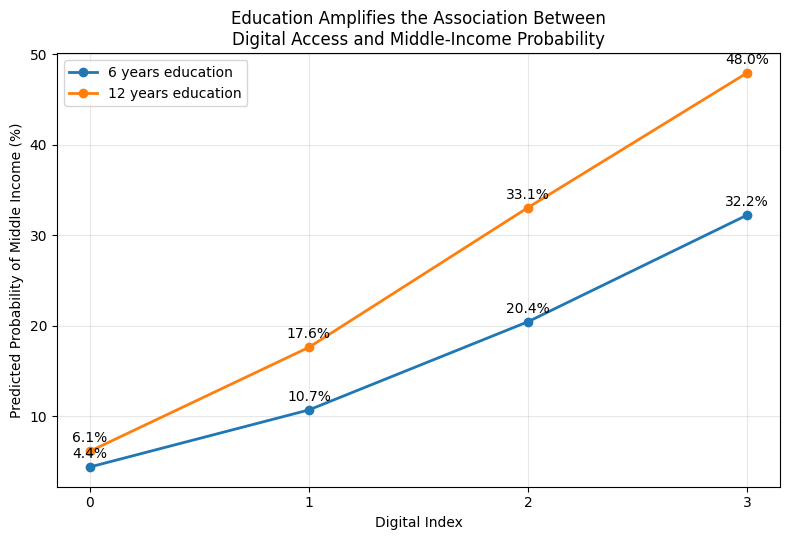

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5.5))

# 6 years education
edu6 = probability_table[
    probability_table['education_years'] == 6
]

# 12 years education
edu12 = probability_table[
    probability_table['education_years'] == 12
]


plt.plot(
    edu6['digital_index'],
    edu6['Middle'],
    marker='o',
    linewidth=2,
    label='6 years education'
)

plt.plot(
    edu12['digital_index'],
    edu12['Middle'],
    marker='o',
    linewidth=2,
    label='12 years education'
)


# Add probability values on the points
for _, row in edu6.iterrows():
    plt.text(
        row['digital_index'],
        row['Middle'] + 1,
        f"{row['Middle']:.1f}%",
        ha='center'
    )

for _, row in edu12.iterrows():
    plt.text(
        row['digital_index'],
        row['Middle'] + 1,
        f"{row['Middle']:.1f}%",
        ha='center'
    )


plt.xlabel('Digital Index')
plt.ylabel('Predicted Probability of Middle Income (%)')

plt.title(
    'Education Amplifies the Association Between\n'
    'Digital Access and Middle-Income Probability'
)

plt.xticks([0, 1, 2, 3])

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'education_digital_middle_income_probability.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 5. Repeat for a second candidate interaction (agri_worker)
Tests a second subgroup dimension flagged in SPR-06, to avoid over-indexing on a single interaction.

In [29]:

INTERACTION_FEATURE= 'agri_worker'
formula_agri = (
    'income_class_code ~ digital_index * agri_worker + age + education_years '
    '+ weekly_workhours + gender_male + disabled + social_participation_index'
)

model_agri = smf.mnlogit(formula_agri, data=df_model)
result_agri = model_agri.fit(
    method='lbfgs',
    maxiter=1000,
    disp=True
)

interaction_term_agri = 'digital_index:agri_worker'
print('Coefficients:')
print(result_agri.params.loc[interaction_term_agri] if interaction_term_agri in result_agri.params.index else 'Not found')
print()
print('P-values:')
print(result_agri.pvalues.loc[interaction_term_agri] if interaction_term_agri in result_agri.pvalues.index else 'Not found')

Coefficients:
0   -2.433675
1   -2.286457
2   -0.178462
Name: digital_index:agri_worker, dtype: float64

P-values:
0    0.003828
1    0.006614
2    0.932483
Name: digital_index:agri_worker, dtype: float64


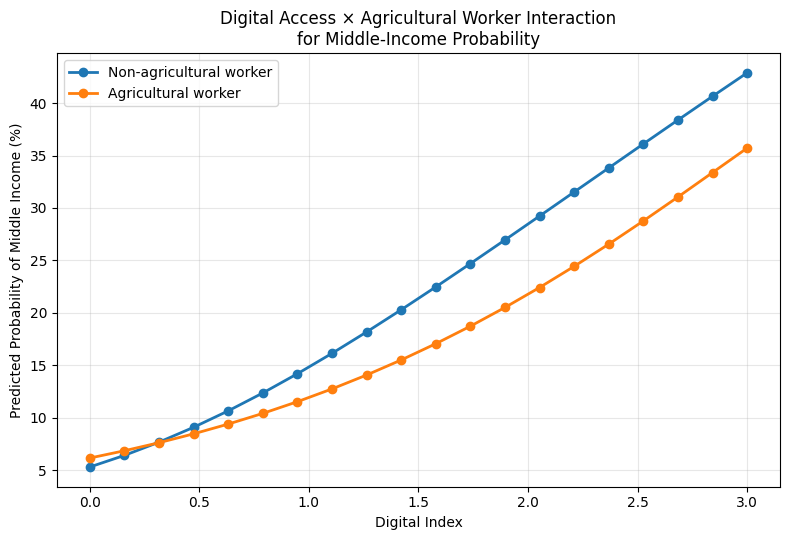

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Digital Index in ORIGINAL units
digital_range_agri = np.linspace(
    df['digital_index'].min(),
    df['digital_index'].max(),
    20
)

# Typical observation from original data
base_row_agri = df.drop(
    columns=[TARGET_COL],
    errors='ignore'
).median(numeric_only=True)


def predict_agri_curve(agri_value):

    rows = []

    for d in digital_range_agri:

        row = base_row_agri.copy()

        row['digital_index'] = d
        row['agri_worker'] = agri_value

        rows.append(row)

    pred_df = pd.DataFrame(rows)

    # Scale ONLY the continuous variables
    # using the SAME scaler used for model fitting
    pred_df[continuous_cols] = scaler.transform(
        pred_df[continuous_cols]
    )

    # Use agriculture interaction model
    probs = result_agri.predict(pred_df)

    return probs


# Predictions
probs_non_agri = predict_agri_curve(0)
probs_agri = predict_agri_curve(1)

# Class mapping:
# 0 = No_income
# 1 = Lower
# 2 = Middle
# 3 = Upper

middle_class = 2



# Plot
plt.figure(figsize=(8, 5.5))

plt.plot(
    digital_range_agri,
    probs_non_agri[middle_class] * 100,
    marker='o',
    linewidth=2,
    label='Non-agricultural worker'
)

plt.plot(
    digital_range_agri,
    probs_agri[middle_class] * 100,
    marker='o',
    linewidth=2,
    label='Agricultural worker'
)

plt.xlabel('Digital Index')

plt.ylabel(
    'Predicted Probability of Middle Income (%)'
)

plt.title(
    'Digital Access × Agricultural Worker Interaction\n'
    'for Middle-Income Probability'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    'digital_agri_middle_income_probability.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 6. Save results table

In [37]:
import os
import pandas as pd

os.makedirs('results/tables', exist_ok=True)

interaction_summary = pd.DataFrame({
    'interaction': [
        'digital_index × education_years',
        'digital_index × education_years',
        'digital_index × education_years',
        'digital_index × agri_worker',
        'digital_index × agri_worker',
        'digital_index × agri_worker'
    ],

    'income_comparison': [
        'Lower vs No_income',
        'Middle vs No_income',
        'Upper vs No_income',
        'Lower vs No_income',
        'Middle vs No_income',
        'Upper vs No_income'
    ],

    'coefficient': [
        result.params.loc['digital_index:education_years', 0],
        result.params.loc['digital_index:education_years', 1],
        result.params.loc['digital_index:education_years', 2],

        result_agri.params.loc['digital_index:agri_worker', 0],
        result_agri.params.loc['digital_index:agri_worker', 1],
        result_agri.params.loc['digital_index:agri_worker', 2]
    ],

    'p_value': [
        result.pvalues.loc['digital_index:education_years', 0],
        result.pvalues.loc['digital_index:education_years', 1],
        result.pvalues.loc['digital_index:education_years', 2],

        result_agri.pvalues.loc['digital_index:agri_worker', 0],
        result_agri.pvalues.loc['digital_index:agri_worker', 1],
        result_agri.pvalues.loc['digital_index:agri_worker', 2]
    ]
})

interaction_summary.to_csv(
    'interaction_analysis_summary.csv',
    index=False
)

print('Saved interaction analysis summary.')


Saved interaction analysis summary.


## 7. Written conclusion

- **Interaction confirmed or ruled out:**  
  The interaction between **digital access and education years was confirmed**. The interaction term was positive and statistically significant for all three income comparisons relative to the No-income class: Lower (β = 0.1977, p < 0.001), Middle (β = 0.2379, p < 0.001), and Upper (β = 0.2586, p < 0.001). This shows that the relationship between digital access and income differs according to education level.

  The **digital access × agricultural-worker interaction was only partially confirmed**. It was significant for Lower (β = -2.4337, p = 0.0038) and Middle income (β = -2.2865, p = 0.0066), but not for Upper income (β = -0.1785, p = 0.9325).

- **Direction of the effect (does digital access matter more or less within this subgroup):**  
  Education has a **positive moderating effect**. As education increases, digital access is associated more strongly with being in higher income classes rather than having no income. The interaction also becomes slightly stronger from Lower to Middle to Upper income, suggesting that education may improve an individual's ability to translate digital access into greater economic advantage.

  In contrast, agricultural-worker status has a **negative moderating effect for the Lower and Middle income classes**. This suggests that the income-related association of digital access is weaker among agricultural workers than among non-agricultural workers for these income levels. No clear agricultural-worker moderation was found for the Upper-income class.

- **Additional predicted-probability analysis:**  
  To make the education interaction easier to interpret, predicted income probabilities were compared for individuals with **6 years and 12 years of education** across Digital Index values from 0 to 3. At low digital access, the two education groups had relatively similar predicted income distributions. However, the difference became much larger as digital access increased.

  At Digital Index = 3, the predicted probability of **Middle income** was 32.24% for the 6-year education group compared with 47.96% for the 12-year group. From Digital Index 0 to 3, Middle-income probability increased by about **27.85 percentage points** for the 6-year group but by **41.83 percentage points** for the 12-year group. Upper-income probability also increased from 0.02% to 0.66% for the 6-year group, compared with 0.05% to 2.19% for the 12-year group. These results provide a more practical illustration of the interaction: higher education is associated with a greater shift away from No income and toward Middle and Upper income as digital access increases.

- **How this connects to the SPR-06 SHAP-based subgroup finding:**  
  SPR-06 showed that the importance and contribution of digital-related features differed across subgroups, particularly across education and agricultural-worker groups. The present interaction analysis extends that descriptive SHAP finding by formally testing whether these subgroup differences correspond to statistically different relationships between digital access and income. The results provide strong evidence for an education-based interaction and more selective evidence for an agricultural-worker interaction.

### Overall finding

The results suggest that **digital access alone does not have the same income-related association for everyone**. Education appears to strengthen the ability to translate digital access into better economic positioning, while agricultural employment may limit this advantage for Lower and Middle income groups. Therefore, the digital divide may involve not only differences in access to digital resources, but also differences in people's capacity to convert that access into economic benefit.